### Assignment 1: Can we use machine learning to identify low rating hospitals?

There is a heated discussion about the quality of care in U.S. hospitals. Recent studies in this area suggest that the quality of care varies largely from one hospital to another. That is, some hospitals provide much better care to their patients than do other hospitals. 

Imagine you are one of the decision-makers in the public health domain and you are tasked with identifying the hospitals which have a quality of care less than that of U.S. average. For this task, we have a data set from the Centers for Medicare & Medicaid Services (CMS.gov). The data includes useful information about the majority of hospitals in the nation (3,502 hospitals). The target variable in our data set is called “low_rating”, which is a binary variable that is equal to one if the overall quality rating of the hospital is below the U.S. average and is equal to zero if the overall quality rating of the hospital is equal to or above U.S. average.


We are tasked to build a deep learning model to accurately predict which hospitals have a low rating when compared to U.S. average.

Please answer the questions right below the question cells (create a new cell right below the question cell). If there is any need to provide answer in text form, please use a Markdown cell. After answering all of the questions, save the notebook, export as PDF, and submit through Blackboard.

Good Luck!


We begin with importing the necessary packages and reading the data file:

In [1]:
# !pip uninstall tensorflow -y
!pip install tensorflow
!pip install keras
!pip install scikeras

  Using cached scikeras-0.13.0-py3-none-any.whl.metadata (3.1 kB)
Using cached scikeras-0.13.0-py3-none-any.whl (26 kB)


In [2]:
# Import packages:

import sys
import pandas as pd
pd.set_option('display.max_rows', 50)
import numpy as np
np.set_printoptions(threshold=sys.maxsize)
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import seaborn as sns
from category_encoders import *

# sklearn imports:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler

# tensorflow imports:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import losses
from tensorflow.keras import layers
from tensorflow.keras import preprocessing
from tensorflow.keras.optimizers import RMSprop, Adam

# keras imports:
from keras.models import Sequential
from scikeras.wrappers import KerasRegressor
from keras.backend import clear_session
from keras.layers import LSTM, Activation, Dense, Dropout, Input, Dropout, Normalization, BatchNormalization, Embedding
from keras.models import Model

2026-03-31 12:19:04.921976: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-31 12:19:04.968967: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/opt/conda/lib/python3.12/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
/opt/conda/lib/python3.12/site

In [3]:
data = pd.read_csv("Hospital_General_Information.csv")
data.head()

,Provider.ID,Hospital.Name,Address,City,State,ZIP.Code,County.Name,Phone.Number,Hospital.Type,Hospital.Ownership,Emergency.Services,Mortality.national.comparison,Safety.of.care.national.comparison,Patient.experience.national.comparison,Effectiveness.of.care.national.comparison,Timeliness.of.care.national.comparison,Efficient.use.of.medical.imaging.national.comparison,Location,low_rating
0,10005,MARSHALL MEDICAL CENTER SOUTH,2505 U S HIGHWAY 431 NORTH,BOAZ,AL,35957,MARSHALL,2565938310,Acute Care Hospitals,Government - Hospital District or Authority,True,Below the national average,Same as the national average,Same as the national average,Same as the national average,Above the national average,Below the national average,"2505 U S HIGHWAY 431 NORTH\nBOAZ, AL\n",0
1,10012,DEKALB REGIONAL MEDICAL CENTER,200 MED CENTER DRIVE,FORT PAYNE,AL,35968,DE KALB,2568453150,Acute Care Hospitals,Proprietary,True,Below the national average,Same as the national average,Same as the national average,Same as the national average,Above the national average,Same as the national average,"200 MED CENTER DRIVE\nFORT PAYNE, AL\n",0
2,10032,WEDOWEE HOSPITAL,209 NORTH MAIN STREET,WEDOWEE,AL,36278,RANDOLPH,2563572111,Acute Care Hospitals,Government - Hospital District or Authority,True,Same as the national average,Not Available,Not Available,Same as the national average,Same as the national average,Not Available,"209 NORTH MAIN STREET\nWEDOWEE, AL\n",0
3,10131,CRESTWOOD MEDICAL CENTER,ONE HOSPITAL DR SE,HUNTSVILLE,AL,35801,MADISON,2568823100,Acute Care Hospitals,Proprietary,True,Below the national average,Above the national average,Same as the national average,Same as the national average,Same as the national average,Same as the national average,"ONE HOSPITAL DR SE\nHUNTSVILLE, AL\n",0
4,20018,YUKON KUSKOKWIM DELTA REG HOSPITAL,PO BOX 287,BETHEL,AK,99559,BETHEL,9075436300,Acute Care Hospitals,Tribal,True,Same as the national average,Not Available,Below the national average,Not Available,Not Available,Not Available,"PO BOX 287\nBETHEL, AK\n",0


There are several columns that we don't use in the analysis. So, we create a new dataframe from the original dataframe (data) and exclude the columns that should not be used in the analysis. We call this new dataframe df.

In [4]:
df = data.drop(columns = ['Provider.ID', 'Hospital.Name', 'Address', 'City', 'ZIP.Code',
       'County.Name', 'Phone.Number','Location'])

Now, we go ahead and use BaseNEncoder from package category_encoders to encode categorical predictors:

In [5]:
from category_encoders import *

In [6]:
encoder = BaseNEncoder(cols=['State', 'Hospital.Type', 'Hospital.Ownership', 'Emergency.Services',
       'Mortality.national.comparison', 'Safety.of.care.national.comparison',
       'Patient.experience.national.comparison',
       'Effectiveness.of.care.national.comparison',
       'Timeliness.of.care.national.comparison',
       'Efficient.use.of.medical.imaging.national.comparison']).fit(df)

df = encoder.transform(df)

Now, we separate the predictors from the target. X includes our predictors and y is the target variable:

In [7]:
X = df.drop(columns = 'low_rating')

Y = df['low_rating']

Let's scale the data before we build our model:

In [8]:
feature_list = X.columns
scalar = MinMaxScaler()
scalar.fit(X)
X = scalar.transform(X)

le = LabelEncoder()
y = le.fit_transform(Y)

Let's split df into train and test data. We use 80% of df in the train data and the remaining data in the test data:

In [9]:
trainData, testData, trainLabels, testLabels = \
train_test_split(X, y, train_size = .8,random_state = 1)

We design a deep learning model:

In [10]:
# Clear the previous model:
clear_session()

model = Sequential()
model.add(Dense(64, input_dim=trainData.shape[1], activation='relu'))
model.add(Normalization())
model.add(BatchNormalization())
model.add(Dense(32, activation='relu'))
model.add(Normalization())
model.add(BatchNormalization())
model.add(Dropout(0.5, seed=1))
model.add(Dense(1, activation='sigmoid'))
model.summary()

/opt/conda/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-03-31 12:20:15.472736: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization (Normalization)   │ (None, 64)             │           129 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization_1 (Normalization) │ (None, 32)             │            65 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,803 (18.77 KB)

 Trainable params: 4,417 (17.25 KB)

 Non-trainable params: 386 (1.52 KB)

#### Q1: [1 point] How many hidden layers do we have in the network above? 

## My Answer

There are two hidden layers in the neural network above and they both use the "relu" activation function. Since Normalization, BatchNormalization, and Dropout layers are still layers but they are not considered separate hidden layers. Additionally, even though the first Dense layer using the "relu" activation function is technically feeding in the data, it still fits the definition of a hidden layer.

#### Q2: [1 point] What is the activation function in the output layer?

## My Answer

The activation function of the output layer is "sigmoid." This is very common for neural networks used in binary classification tasks.

Now, we go ahead and compile and fit it:

In [11]:
model.compile(loss='binary_crossentropy', 
              optimizer='RMSprop', 
              metrics = ['AUC'])

In [12]:
history = model.fit(trainData, trainLabels, 
          epochs=20, 
          batch_size=32, 
          shuffle=True,   
          verbose=1,
          validation_split=0.2)

Epoch 1/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.7452 - loss: 0.6996 - val_AUC: 0.8909 - val_loss: 0.5166
Epoch 2/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - AUC: 0.8334 - loss: 0.5010 - val_AUC: 0.9179 - val_loss: 0.3845
Epoch 3/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - AUC: 0.8636 - loss: 0.4231 - val_AUC: 0.9232 - val_loss: 0.3250
Epoch 4/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - AUC: 0.8765 - loss: 0.3806 - val_AUC: 0.9243 - val_loss: 0.3004
Epoch 5/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - AUC: 0.8855 - loss: 0.3536 - val_AUC: 0.9273 - val_loss: 0.2866
Epoch 6/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - AUC: 0.8857 - loss: 0.3440 - val_AUC: 0.9315 - val_loss: 0.2759
Epoch 7/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - AUC: 0.8997 - loss: 0.3279 - val_AUC: 0.9297 - val_loss: 0.2754
Epoch 8/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - AUC: 0.9038 - loss: 0.3162 - val_AUC: 0.9349 - val_loss: 0.2656
Epoch 9/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - AUC: 0.9117 - loss: 

#### Q3: [2 points] During each epoch above, how many times network weights get updated? 

## My Answer

During each training epoch, here is how we can find the number of times the network weights get updated:

Total Hospitals in Dataset: 3,502

80% of the train/test split: 3,502 x 0.80 = 2,801.6

20% of the validation_split: 2,802 x 0.20 = 560.4

Actual training samples: 2,802 - 560 = 2,242

batch_size of 32 processing: 2,242 / 32 = 70.06 

## During each epoch, the network weights get updated 71 times.

Let's take a look at the performance of the model over epochs:

dict_keys(['AUC', 'loss', 'val_AUC', 'val_loss'])


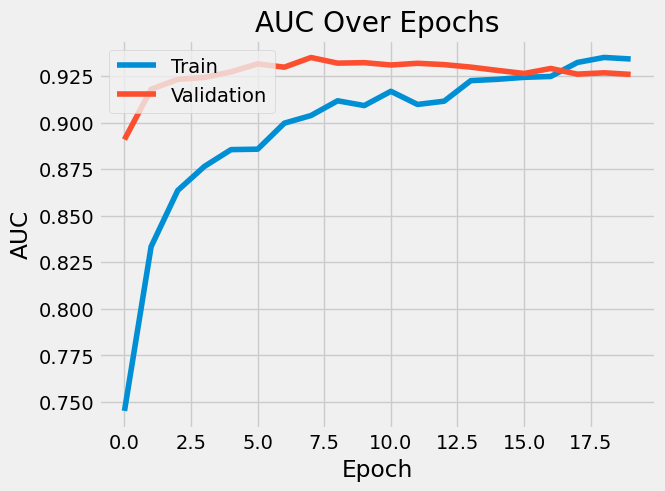

In [13]:
print(history.history.keys())

plt.plot(history.history['AUC'])
plt.plot(history.history['val_AUC'])
plt.title('AUC Over Epochs')
plt.ylabel('AUC')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

#### Q4: [1 point] By looking at the plot above, determine how many epochs (approximately) would be sufficient for this case? 

## My Answer

Based on the plot above, 20 epochs are sufficient. By this point, the validation AUC has plateaued, and the training AUC has converged with it, indicating that additional training is "unlikely" to yield significant generalization gains. However, to confirm the model has truly reached its limit and isn't just in a temporary plateau, extending training to 30 epochs would be an important step to ensure we do not miss a late-stage improvement. Additionally, the validation AUC has not begun to drop yet. This means that the model has not started to overfit the training data yet.

#### Q5: [1 point] Is the model overfitting? 

## My Answer

Based on the AUC plot above, the model is not overfitting. It is actually underfitting the data until around epoch 16. This is where we see the training AUC curve jump above the validation curve, and we notice that the validation AUC has not begun to drop. As mentioned above, if the validation AUC drops, the model has begun to overfit the training dataset.

Now that we built the model, we can use it to make predictions over testData. This will allow us to evaluate the model:

In [14]:
predictions = (model.predict(testData) > 0.5).astype("int32").flatten()
predictionProbabilities = model.predict(testData).flatten()

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


In [15]:
# Importing function that can be used to calculate different metrics such as accuracy, precision, recall.
from sklearn.metrics import * 

def calculateMetricsAndPrint(predictions, predictionsProbabilities, actualLabels):
    accuracy = accuracy_score(actualLabels, predictions) * 100
    precisionNegative = precision_score(actualLabels, predictions, average = None)[0] * 100
    precisionPositive = precision_score(actualLabels, predictions, average = None)[1] * 100
    recallNegative = recall_score(actualLabels, predictions, average = None)[0] * 100
    recallPositive = recall_score(actualLabels, predictions, average = None)[1] * 100
    auc = roc_auc_score(actualLabels, predictionsProbabilities) * 100
    
    print("Accuracy: %.2f\nPrecisionNegative: %.2f\nPrecisionPositive: %.2f\nRecallNegative: %.2f\nRecallPositive: %.2f\nAUC Score: %.2f\n" % 
          (accuracy, precisionNegative, precisionPositive, recallNegative, recallPositive, auc))
    
calculateMetricsAndPrint(predictions, predictionProbabilities, testLabels) # Get model performances

Accuracy: 85.02
PrecisionNegative: 87.80
PrecisionPositive: 72.44
RecallNegative: 93.51
RecallPositive: 56.79
AUC Score: 88.23



We can also create the ROC curve:

AUC Score = 88.235


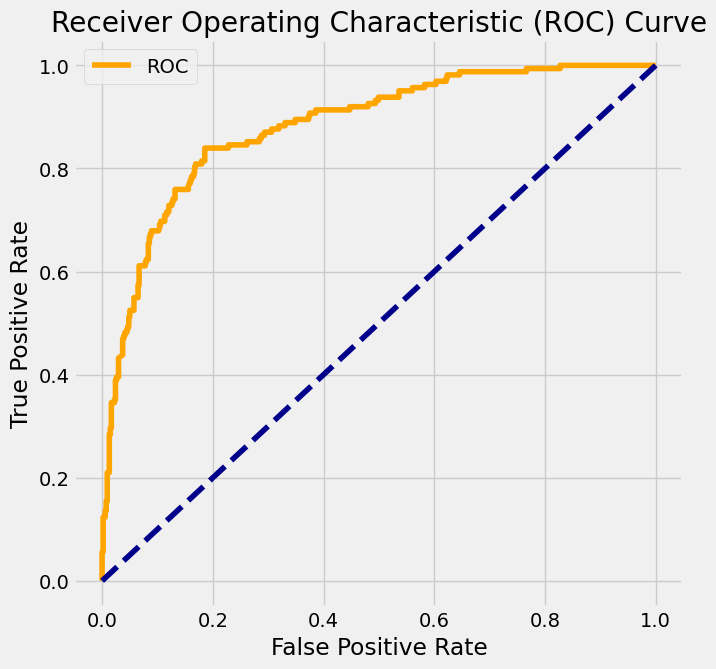

In [16]:
def plot_roc_curve(fpr, tpr):
    plt.plot(fpr, tpr, color='orange', label='ROC')
    plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend()
    plt.show()
    
pos_probs = predictionProbabilities

fpr, tpr, thresholds = roc_curve(testLabels, pos_probs, pos_label = 1)

# calculate scores
lr_auc = roc_auc_score(testLabels, pos_probs)
print('AUC Score = %.3f' % (lr_auc * 100))
plt.rcParams['figure.figsize'] = [7, 7]
plot_roc_curve(fpr, tpr)

#### Q6: [4 points] Redesign the deep learning model with the following specifications:

* Two hidden layers with 16 units in each. You can use the activation function that you desire.
* Output layer with sigmoid activation function.
* for the optimizer, please use RMSprop.
* Fit the model using 30 epochs.
* Create the ROC curve and calculate the AUC for this model (based on testData)


## My Answer

In [29]:
class_imbalance_low_rating = np.mean(Y)

print(class_imbalance_low_rating)

0.22158766419189035


In [66]:
clear_session()

model = Sequential()
model.add(Dense(16,input_dim=trainData.shape[1], activation='swish'))
model.add(BatchNormalization())
model.add(Dense(16, activation='swish'))
model.add(BatchNormalization())
model.add(Dense(1, activation='sigmoid'))
model.summary()


model.compile(
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['AUC']
)

#applying the custom weight imbalance
custom_class_weights = {0: 0.64, 1: 2.26}

history = model.fit(
    trainData, trainLabels,
    epochs=30,
    batch_size=32,
    class_weight=custom_class_weights,
    verbose=1
)

/opt/conda/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 945 (3.69 KB)

 Trainable params: 881 (3.44 KB)

 Non-trainable params: 64 (256.00 B)

Epoch 1/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - AUC: 0.7029 - loss: 0.6425
Epoch 2/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.8500 - loss: 0.5018
Epoch 3/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.8813 - loss: 0.4514
Epoch 4/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.9011 - loss: 0.4135
Epoch 5/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.9021 - loss: 0.4034
Epoch 6/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.9093 - loss: 0.3869
Epoch 7/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.9129 - loss: 0.3775
Epoch 8/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.9129 - loss: 0.3759
Epoch 9/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.9145 - loss: 0.3707
Epoch 10/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.9143 - loss: 0.3697
Epoch 11/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - AUC: 0.9164 - loss: 0.3651
Epoch 12/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.9221 - loss: 0.3530
Epoch 13/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/ste

In [67]:
# Importing function that can be used to calculate different metrics such as accuracy, precision, recall.
from sklearn.metrics import * 

predictionProbabilities = model.predict(testData).ravel()

pos_probs = predictionProbabilities

def calculateMetricsAndPrint(predictions, predictionsProbabilities, actualLabels):
    accuracy = accuracy_score(actualLabels, predictions) * 100
    precisionNegative = precision_score(actualLabels, predictions, average = None)[0] * 100
    precisionPositive = precision_score(actualLabels, predictions, average = None)[1] * 100
    recallNegative = recall_score(actualLabels, predictions, average = None)[0] * 100
    recallPositive = recall_score(actualLabels, predictions, average = None)[1] * 100
    auc = roc_auc_score(actualLabels, predictionsProbabilities) * 100
    
    print("Accuracy: %.2f\nPrecisionNegative: %.2f\nPrecisionPositive: %.2f\nRecallNegative: %.2f\nRecallPositive: %.2f\nAUC Score: %.2f\n" % 
          (accuracy, precisionNegative, precisionPositive, recallNegative, recallPositive, auc))
    
calculateMetricsAndPrint(predictions, predictionProbabilities, testLabels) # Get model performances

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Accuracy: 85.02
PrecisionNegative: 87.80
PrecisionPositive: 72.44
RecallNegative: 93.51
RecallPositive: 56.79
AUC Score: 90.08



AUC Score = 90.079


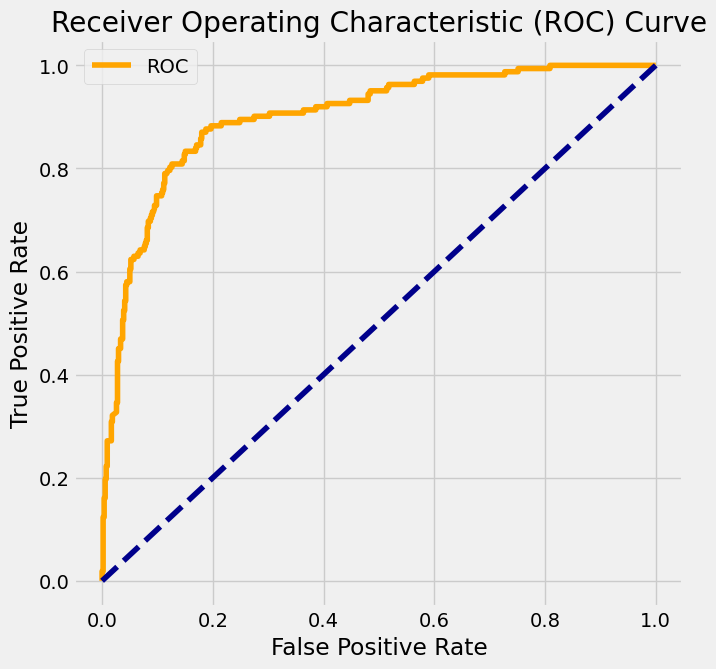

In [68]:
def plot_roc_curve(fpr, tpr):
    plt.plot(fpr, tpr, color='orange', label='ROC')
    plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend()
    plt.show()
    
pos_probs = predictionProbabilities

fpr, tpr, thresholds = roc_curve(testLabels, pos_probs, pos_label = 1)

# calculate scores
lr_auc = roc_auc_score(testLabels, pos_probs)
print('AUC Score = %.3f' % (lr_auc * 100))
plt.rcParams['figure.figsize'] = [7, 7]
plot_roc_curve(fpr, tpr)